In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../data/cancer_data.csv")
X = data.copy()
X.shape

(748, 20)

In [3]:
## here we cannot drop the germline column

original_columns = X.columns
X = X.dropna(axis = 1, thresh=int(0.5*len(X)))
remaining_columns = X.columns
dropped_columns = original_columns.difference(remaining_columns)
print("Dropped columns:", dropped_columns)

Dropped columns: Index(['Cancer Syndrome', 'Germline', 'Hallmark', 'Other Germline Mut',
       'Other Syndrome', 'Translocation Partner', 'Tumour Types(Germline)'],
      dtype='object')


In [4]:
import pandas as pd

# Load data
data = pd.read_csv("../data/cancer_data.csv")
X = data.copy()

# Drop columns with more than 50% missing values
original_columns = X.columns
X = X.dropna(axis=1, thresh=int(0.5 * len(X)))
remaining_columns = X.columns
dropped_columns = original_columns.difference(remaining_columns)
print("Dropped columns:", dropped_columns)

# Drop rows where 'Role in Cancer' is missing
X.dropna(subset=['Role in Cancer'], inplace=True)

# Pop 'Role in Cancer' column
y = X.pop("Role in Cancer")

# Get unique values from each column
unique_values = {col: X[col].unique() for col in X.columns}

# Create a DataFrame with unique values for each column
unique_values_df = pd.DataFrame({col: pd.Series(unique_values[col]) for col in unique_values})

# Save the DataFrame to an Excel file
unique_values_df.to_excel("unique_values.xlsx", index=False)

print("Unique values have been saved to 'unique_values.xlsx'.")


Dropped columns: Index(['Cancer Syndrome', 'Germline', 'Hallmark', 'Other Germline Mut',
       'Other Syndrome', 'Translocation Partner', 'Tumour Types(Germline)'],
      dtype='object')
Unique values have been saved to 'unique_values.xlsx'.


# Column Removal Summary

### Dropped Columns
The following columns were dropped due to insufficient non-NA values:

- Cancer Syndrome (can be removed)
- Germline (cannot remove will replace the missing with "no")
- Hallmark (cannot remove will replace the missing with "no")
- Other Germline Mut (can replace missing values with "no")
- Other Syndrome (can be removed)
- Translocation Partner (can be removed)
- Tumour Types (Germline) - (can be removed)

---

### Remaining Columns
The following columns remain in the dataset:

- Gene Symbol
- Name
- Entrez GeneId
- Genome Location
- Tier
- Chr Band
- Somatic
- Tumour Types (Somatic) - (can be removed)
- Tissue Type
- Molecular Genetics
- Mutation Types
- Synonyms


In [5]:
X.columns

Index(['Gene Symbol', 'Name', 'Entrez GeneId', 'Genome Location', 'Tier',
       'Chr Band', 'Somatic', 'Tumour Types(Somatic)', 'Tissue Type',
       'Molecular Genetics', 'Role in Cancer', 'Mutation Types', 'Synonyms'],
      dtype='object')

In [6]:
# we cant remove missing values because some of these also cause cancer. (you can check the somatic and germline columns to verify)
X.dropna(subset=['Role in Cancer'], inplace=True)

In [7]:
y = X.pop("Role in Cancer")

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.33)

In [9]:
X.select_dtypes("object").columns

Index(['Gene Symbol', 'Name', 'Genome Location', 'Chr Band', 'Somatic',
       'Tumour Types(Somatic)', 'Tissue Type', 'Molecular Genetics',
       'Mutation Types', 'Synonyms'],
      dtype='object')

In [10]:
X.select_dtypes("number").columns

Index(['Entrez GeneId', 'Tier'], dtype='object')

In [11]:

X.select_dtypes(exclude=["number"]).fillna("unknown", inplace=True)

## why are you filling the entrez id column which is a uid with 0 ??
X.select_dtypes(exclude=["object"]).fillna(0, inplace=True)

In [12]:
X.select_dtypes(include="object").columns

Index(['Gene Symbol', 'Name', 'Genome Location', 'Chr Band', 'Somatic',
       'Tumour Types(Somatic)', 'Tissue Type', 'Molecular Genetics',
       'Mutation Types', 'Synonyms'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ord = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value= -1)

X_train=ord.fit_transform(X_train)
X_test=ord.transform(X_test)

In [ ]:
y_train=ord.fit_transform(pd.DataFrame(y_train))
y_test=ord.transform(pd.DataFrame(y_test))

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns


c:\Users\anish\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:42:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


<Axes: >

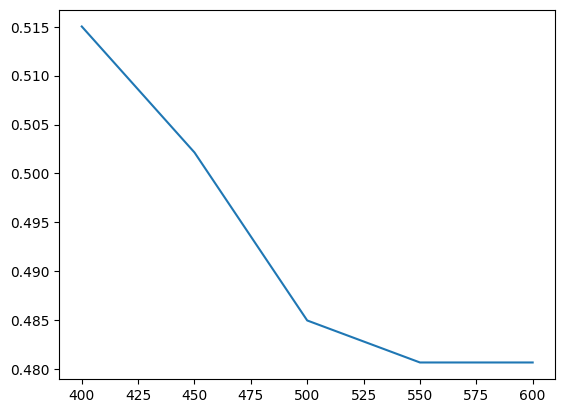

In [17]:
estms = [400, 450, 500, 550,600]
acc_score = []
for est in estms:
    model = XGBClassifier(device = 'cuda', n_estimators = est, learning_rate = 0.03)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc_score.append(accuracy_score(y_test, preds))

sns.lineplot(x=estms, y=acc_score)

<Axes: >

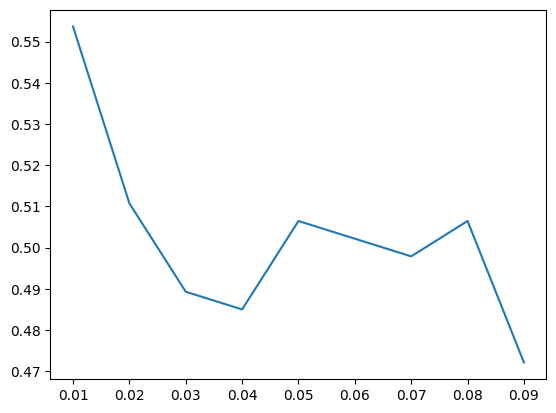

In [18]:
rates = [0.01, 0.02, 0.03, 0.04,0.05, 0.06, 0.07, 0.08, 0.09]
acc_score = []
for rate in rates:
    model = XGBClassifier(device = 'cuda', n_estimators = 475, learning_rate = rate)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc_score.append(accuracy_score(y_test, preds))

sns.lineplot(x=rates, y=acc_score)

In [ ]:
final_model = XGBClassifier(device = 'cuda', n_estimators = 475, learning_rate = 0.03)

final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

accuracy_score(y_test, final_pred)

0.51931330472103